In [1]:
from plot_tmi_results import compute_tmi_from_singular_values
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import h5py
import csv
from FSS.DataCollapse import *

In [2]:
def read_tmi_results_to_df(p_fixed, p_fixed_name, L_values=None, n=0, threshold=1e-15):
    """
    Read singular values from HDF5 files, compute TMI statistics, and return results as a DataFrame.
    Scans for all available data files with different p_c values and combines them into one CSV.
    
    Parameters:
    -----------
    p_fixed : float
        Fixed parameter value
    p_fixed_name : str
        Name of fixed parameter ('pproj' or 'pctrl')
    L_values : list, optional
        List of L values to process. If None, discovers all available L values.
    n : int, optional
        Parameter for TMI computation
    threshold : float, optional
        Threshold for TMI computation
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with MultiIndex (p, L) containing TMI observations
    """
    import glob
    # Find all relevant data files using glob
    file_pattern = f'tmi_fine_L*_{p_fixed_name}{p_fixed:.3f}_pc*'
    all_files = glob.glob(file_pattern)
    
    # Extract unique L values and p_c values from filenames
    if L_values is None:
        L_values = sorted(list(set([int(f.split('_')[2][1:]) for f in all_files])))
    p_c_values = sorted(list(set([float(f.split('_pc')[1]) for f in all_files])))
    
    output_filename = f'tmi_results_combined_{p_fixed_name}{p_fixed:.3f}.csv'
    p_scan_name = 'pctrl' if p_fixed_name == 'pproj' else 'pproj'
    
    # If CSV exists, read directly from it
    if os.path.exists(output_filename):
        print(f"Reading existing results from {output_filename}")
        data_list = []
        with open(output_filename, mode='r') as file:
            reader = csv.DictReader(file)
            for row in reader:
                data_list.append({
                    'p': float(row[f'{p_scan_name}_value']),
                    'L': int(row['L']),
                    'observations': float(row['tmi_value'])
                })
    else:
        data_list = []
        
        # Write results to CSV and collect data for DataFrame
        with open(output_filename, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['L', p_fixed_name, p_scan_name + '_index', p_scan_name + '_value', 'p_c', 'sample_idx', 'tmi_value'])
            
            for L in L_values:
                for p_c in p_c_values:
                    filename = f'tmi_fine_L{L}_{p_fixed_name}{p_fixed:.3f}_pc{p_c}/final_results_L{L}.h5'
                    if not os.path.exists(filename):
                        print(f"Warning: File {filename} not found!")
                        continue
                        
                    print(f"\nAnalyzing file: {filename}")
                    with h5py.File(filename, 'r') as f:
                        p_fixed_key = f"{p_fixed_name}{p_fixed:.3f}"
                        p_fixed_group = f[p_fixed_key]
                        p_scan_values = p_fixed_group[p_scan_name][:]
                        sv_group = p_fixed_group['singular_values']
                        
                        num_p_scan = len(p_fixed_group[p_scan_name])
                        
                        for p_scan_idx in range(num_p_scan):
                            num_samples = sv_group[list(sv_group.keys())[0]].shape[1]
                            singular_values = [{
                                key: sv_group[key][p_scan_idx, sample_idx] 
                                for key in sv_group.keys()
                            } for sample_idx in range(num_samples)]
                            
                            # Compute TMI for each sample
                            tmi_values = [compute_tmi_from_singular_values(sv, n, threshold) 
                                        for sv in singular_values]
                            
                            # Write to CSV and collect for DataFrame
                            for sample_idx, tmi_value in enumerate(tmi_values):
                                writer.writerow([L, p_fixed_key, p_scan_idx, p_scan_values[p_scan_idx], p_c, sample_idx, tmi_value])
                                data_list.append({
                                    'p': p_scan_values[p_scan_idx],
                                    'L': L,
                                    'p_c': p_c,
                                    'observations': tmi_value
                                })
    

    # Create DataFrame and group observations
    df = pd.DataFrame(data_list)
    df_grouped = df.groupby(['p', 'L'])['observations'].apply(list).reset_index()
    df_final = df_grouped.set_index(['p', 'L'])
    
    return df_final


In [3]:
p_fixed = 0.643
p_c = 0.473
delta_p = 0.03
L_min = 16
df = read_tmi_results_to_df(p_fixed, p_fixed_name = 'pproj', L_values = [8, 12, 16, 20], threshold=1e-10)
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[p_c - delta_p, p_c + delta_p],Lmin=L_min)
dc.datacollapse(p_c=p_c,nu=1,beta=0.,p_c_vary=True,beta_vary=False,nu_vary=True, max_nfev=1000)

Reading existing results from tmi_results_combined_pproj0.643.csv


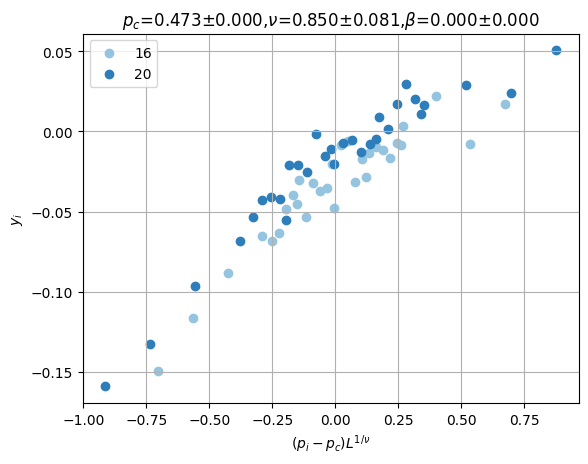

In [4]:
dc.plot_data_collapse()

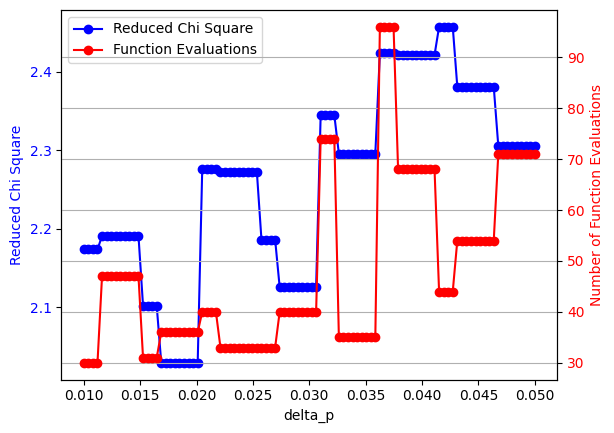

In [5]:
delta_p_values = np.linspace(0.01, 0.05, 100)
redchi_values = []
num_func_evals = []

for delta_p in delta_p_values:
    dc = DataCollapse(df, p_='p', L_='L', params={}, p_range=[p_c - delta_p, p_c + delta_p], Lmin=L_min)
    dc.datacollapse(p_c=p_c, nu=1, beta=0., p_c_vary=True, beta_vary=False, nu_vary=True, max_nfev=1000)
    redchi_values.append(dc.res.redchi)
    num_func_evals.append(dc.res.nfev)
fig, ax1 = plt.subplots()

# Plot redchi on left y-axis
ax1.plot(delta_p_values,redchi_values, 'o-', color='blue', label='Reduced Chi Square')
ax1.set_xlabel('delta_p')
ax1.set_ylabel('Reduced Chi Square', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis and plot nfev
ax2 = ax1.twinx()
ax2.plot(delta_p_values, num_func_evals, 'o-', color='red', label='Function Evaluations')
ax2.set_ylabel('Number of Function Evaluations', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.grid()
plt.show()

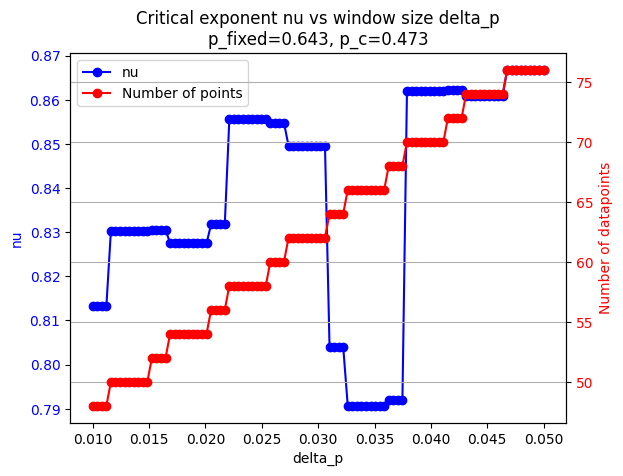

In [6]:
# Extract nu values and number of points for different delta_p
nu_values = []
num_points = []
for delta_p in delta_p_values:
    dc = DataCollapse(df, p_='p', L_='L', params={}, p_range=[p_c - delta_p, p_c + delta_p], Lmin=L_min)
    dc.datacollapse(p_c=p_c, nu=1, beta=0., p_c_vary=True, beta_vary=False, nu_vary=True, max_nfev=1000)
    nu_values.append(dc.nu)
    num_points.append(len(dc.y_i))

fig, ax1 = plt.subplots()

# Plot nu on left y-axis
ax1.plot(delta_p_values, nu_values, 'o-', color='blue', label='nu')
ax1.set_xlabel('delta_p')
ax1.set_ylabel('nu', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis and plot number of points
ax2 = ax1.twinx()
ax2.plot(delta_p_values, num_points, 'o-', color='red', label='Number of points')
ax2.set_ylabel('Number of datapoints', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(f'Critical exponent nu vs window size delta_p\np_fixed={p_fixed:.3f}, p_c={p_c:.3f}')
plt.grid()
plt.show()


In [7]:
df_ = df.map(np.mean)
df_std = df.map(lambda x: np.std(x)/np.sqrt(len(x)))

In [8]:
df_.index.get_level_values('p').unique().size

40

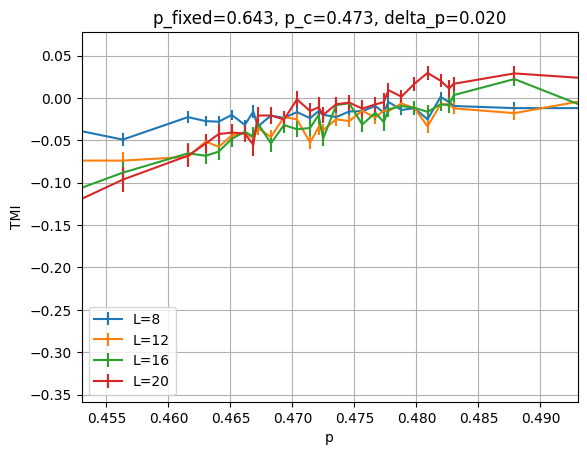

In [9]:
delta_p = 0.02
p_c = 0.473
p_range = [p_c - delta_p, p_c + delta_p]
fig,ax=plt.subplots()
for L in [8,12,16,20]:
    # ax.plot(df_.index.get_level_values('p').unique(),df_['observations'].xs(L,level='L'),label=f'L={L}')
    ax.errorbar(df_.index.get_level_values('p').unique(),df_['observations'].xs(L,level='L'),yerr=df_std['observations'].xs(L,level='L'),label=f'L={L}')
ax.legend()
ax.set_xlabel('p')
ax.set_ylabel('TMI')
ax.set_title(f'p_fixed={p_fixed:.3f}, p_c={p_c:.3f}, delta_p={delta_p:.3f}')
ax.set_xlim(p_range)
ax.grid()
plt.show()

In [10]:
# check whether i am doing the ensemble average correctly
# then report to Haining that the nu equals to 0.7 result does not correspond to the best fit, where as the 
# best fit according to the reduced chi square is 0.9

In [11]:
# Print unique combinations of p and L values
print("Unique (p, L) combinations in the dataset:")
print("\np values:", sorted(df.index.get_level_values('p').unique()))
print("\nL values:", sorted(df.index.get_level_values('L').unique()))


Unique (p, L) combinations in the dataset:

p values: [0.43, 0.43526315789473685, 0.44052631578947365, 0.4457894736842105, 0.45105263157894737, 0.45631578947368423, 0.46157894736842103, 0.46299999999999997, 0.4640526315789473, 0.4651052631578947, 0.46615789473684205, 0.4668421052631579, 0.46721052631578947, 0.4682631578947368, 0.4693157894736842, 0.47036842105263155, 0.4714210526315789, 0.47210526315789475, 0.47247368421052627, 0.4735263157894737, 0.47457894736842104, 0.4756315789473684, 0.47668421052631577, 0.4773684210526316, 0.4777368421052631, 0.4787894736842105, 0.47984210526315785, 0.48089473684210526, 0.4819473684210526, 0.4826315789473684, 0.483, 0.48789473684210527, 0.49315789473684213, 0.498421052631579, 0.5036842105263158, 0.5089473684210526, 0.5142105263157895, 0.5194736842105263, 0.5247368421052632, 0.53]

L values: [8, 12, 16, 20]


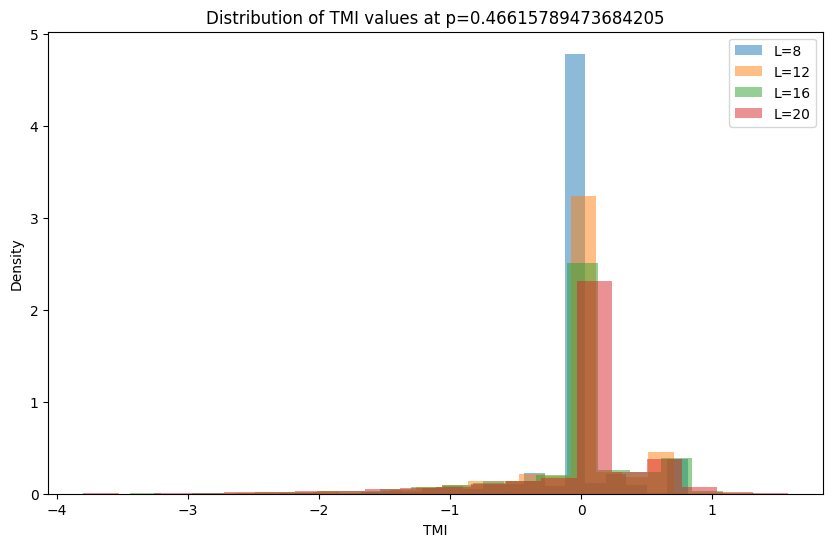

Mean: -0.042012
Standard Error: 0.010232
Number of samples: 3000


In [12]:
# To check why the fluctuation is so large
# For a specific p and L value
p_index = 10
plt.figure(figsize=(10,6))
p = df.index.get_level_values('p').unique()[p_index]
for L in [8,12,16,20]:
    samples = df.loc[(p, L)]['observations']
    plt.hist(samples, bins=20, density=True, alpha=0.5, label=f'L={L}')
plt.title(f'Distribution of TMI values at p={p}')
plt.xlabel('TMI')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"Mean: {np.mean(samples):.6f}")
print(f"Standard Error: {np.std(samples)/np.sqrt(len(samples)):.6f}")
print(f"Number of samples: {len(samples)}")

In [13]:
# try larger sample size
# denser p scan resolutions closer to pc
# try different threshold -- as related to pc and nu

In [29]:
from scratch import read_threshold_results
results = read_threshold_results(p_fixed=0.643, p_fixed_name='pproj')

Loaded data for threshold 1.3e-14
Loaded data for threshold 6.2e-10
Loaded data for threshold 3.8e-13
Loaded data for threshold 1.0e-15
Loaded data for threshold 1.4e-12
Loaded data for threshold 7.0e-14
Loaded data for threshold 5.5e-11
Loaded data for threshold 1.3e-13
Loaded data for threshold 1.1e-14
Loaded data for threshold 2.6e-11
Loaded data for threshold 3.0e-14
Loaded data for threshold 1.0e-10
Loaded data for threshold 3.0e-06
Loaded data for threshold 7.0e-09
Loaded data for threshold 2.1e-09
Loaded data for threshold 6.2e-11
Loaded data for threshold 1.8e-09
Loaded data for threshold 1.4e-10
Loaded data for threshold 3.4e-10
Loaded data for threshold 1.0e-05
Loaded data for threshold 4.3e-13
Loaded data for threshold 1.0e-08
Loaded data for threshold 8.9e-07
Loaded data for threshold 2.3e-08
Loaded data for threshold 4.8e-12
Loaded data for threshold 1.1e-11
Loaded data for threshold 2.1e-12
Loaded data for threshold 1.6e-11
Loaded data for threshold 1.6e-13
Loaded data fo

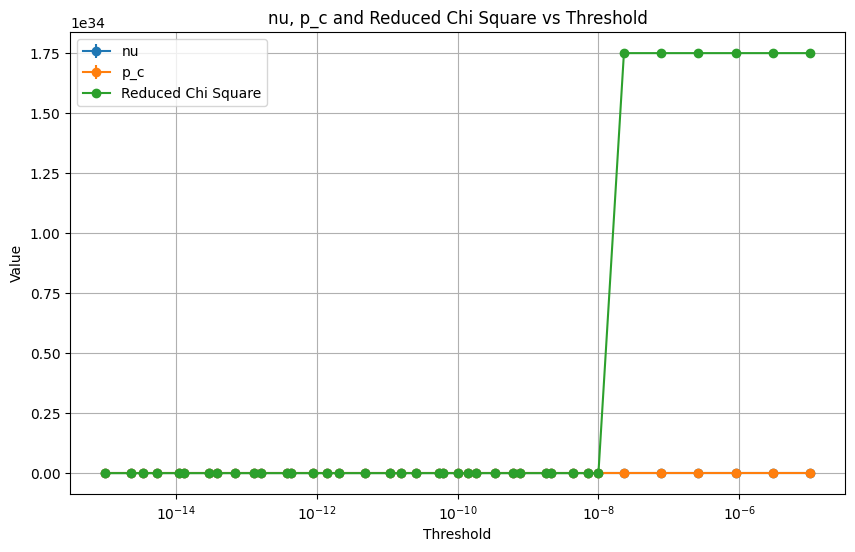

In [39]:
from FSS.DataCollapse import *

p_c = 0.473
delta_p = 0.02
L_min = 16
threshold_values = []
nu_values = []
nu_std = []
pc_values = []
pc_std = []
redchi_values = []
for threshold, df in results.items():
    dc = DataCollapse(df, p_='p', L_='L', params={}, p_range=[p_c - delta_p, p_c + delta_p], Lmin=L_min)
    dc.datacollapse(p_c=p_c, nu=1, beta=0., p_c_vary=True, beta_vary=False, nu_vary=True, max_nfev=1000)
    nu_values.append(dc.res.params['nu'].value)
    nu_std.append(dc.res.params['nu'].stderr)
    pc_values.append(dc.res.params['p_c'].value)
    pc_std.append(dc.res.params['p_c'].stderr)
    redchi_values.append(dc.res.redchi)
    threshold_values.append(threshold)

# Get indices where redchi < 10
good_indices = np.where(redchi_values < 10)[0]

# Now you can use these indices to get the corresponding values
good_thresholds = threshold_values[good_indices]
good_nu = nu_values[good_indices]
good_nu_std = nu_std[good_indices]
good_pc = pc_values[good_indices]
good_pc_std = pc_std[good_indices]
good_redchi = redchi_values[good_indices]

# Create figure with one subplot
plt.figure(figsize=(10,6))
# Plot both nu and pc vs threshold on same axes
plt.semilogx()  # Set x-axis to log scale
plt.errorbar(threshold_values, nu_values, yerr=nu_std, fmt='o-', label='nu')
plt.errorbar(threshold_values, pc_values, yerr=pc_std, fmt='o-', label='p_c')
plt.errorbar(threshold_values, redchi_values, fmt='o-', label='Reduced Chi Square')
plt.xlabel('Threshold')
plt.ylabel('Value') 
plt.title('nu, p_c and Reduced Chi Square vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

In [35]:
print(results.keys())

dict_keys([1.3e-14, 6.2e-10, 3.8e-13, 1e-15, 1.4e-12, 7e-14, 5.5e-11, 1.3e-13, 1.1e-14, 2.6e-11, 3e-14, 1e-10, 3e-06, 7e-09, 2.1e-09, 6.2e-11, 1.8e-09, 1.4e-10, 3.4e-10, 1e-05, 4.3e-13, 1e-08, 8.9e-07, 2.3e-08, 4.8e-12, 1.1e-11, 2.1e-12, 1.6e-11, 1.6e-13, 7.8e-08, 1.8e-10, 3.8e-14, 8.9e-13, 5.5e-15, 3.4e-15, 2.6e-07, 2.3e-15, 7.8e-10, 4.3e-09])
